/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Detected Anomalies:
         Amount  Transaction_ID       Date  Anomaly
990  461.169047             991 2025-04-04       -1
991  614.169315             992 2025-04-04       -1
992  270.293199             993 2025-04-04       -1
993  480.501545             994 2025-04-04       -1
994  226.562487             995 2025-04-04       -1
995  262.862798             996 2025-04-04       -1
996  517.538621             997 2025-04-04       -1
997  306.172603             998 2025-04-04       -1
998  654.032679             999 2025-04-04       -1
999  751.571975            1000 2025-04-04       -1
Precision: 1.00
Recall: 1.00
F1-Score: 1.00


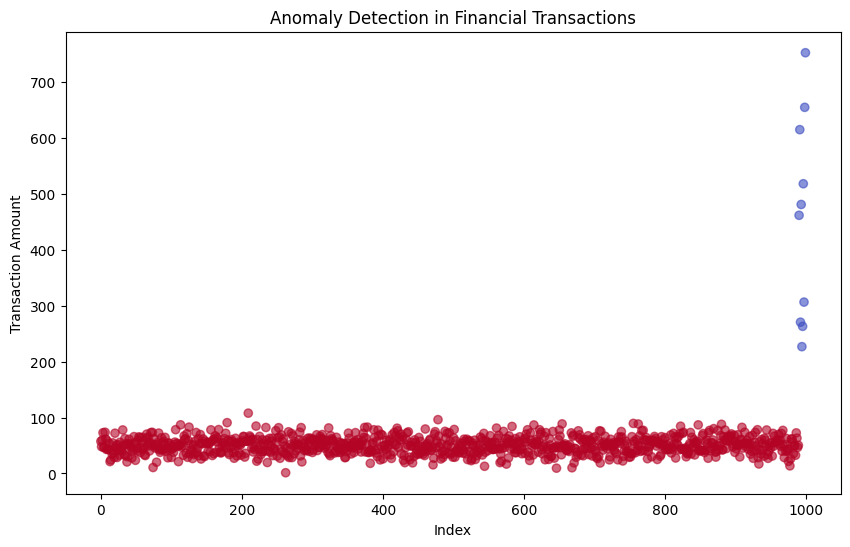

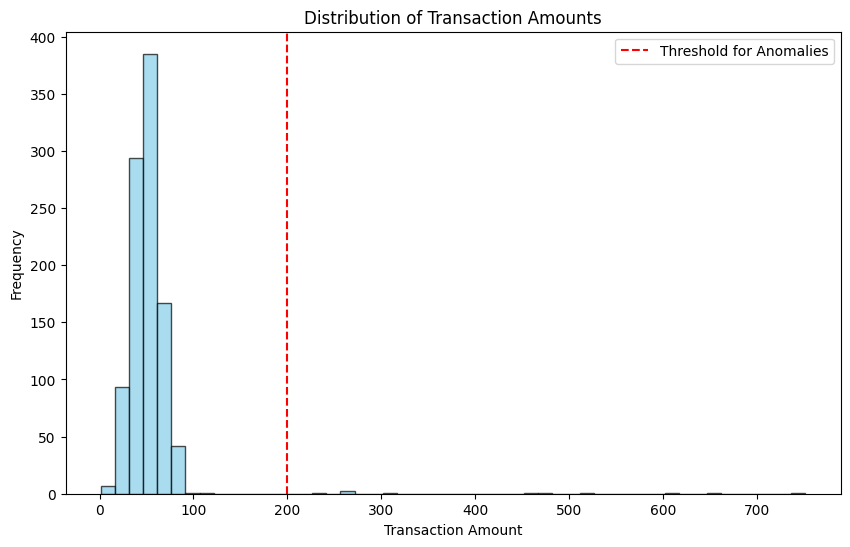

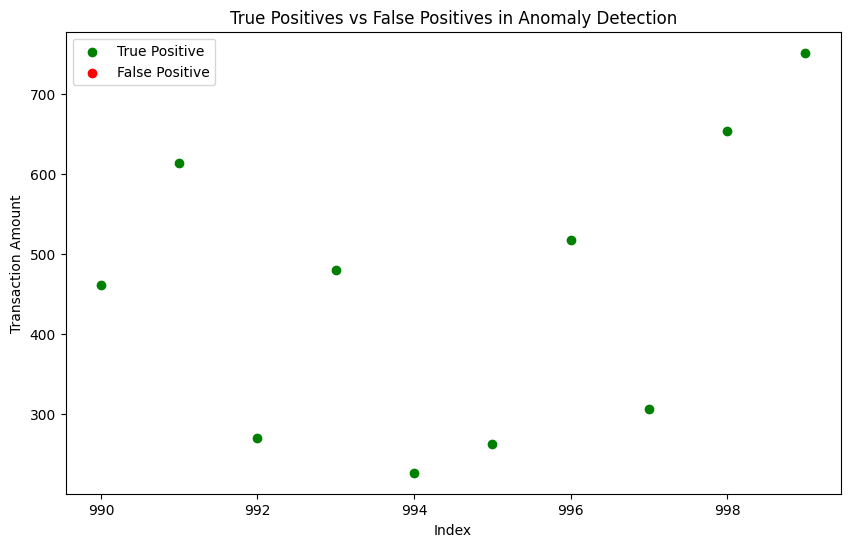

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to generate synthetic financial data for anomaly detection
def generate_synthetic_data(n_samples=1000, anomaly_fraction=0.01):
    np.random.seed(42)
    
    # Generate normal transaction amounts: Normally distributed around $50
    normal_data = np.random.normal(loc=50, scale=15, size=int(n_samples * (1 - anomaly_fraction)))
    
    # Generate anomalous transactions: Uniformly distributed between $200 and $1000
    anomalous_data = np.random.uniform(200, 1000, size=int(n_samples * anomaly_fraction))
    
    # Combine normal and anomalous data (no shuffling)
    all_data = np.concatenate([normal_data, anomalous_data])
    
    # Create a DataFrame with required columns
    df = pd.DataFrame(all_data, columns=['Amount'])
    
    # Optionally add 'Transaction ID' (if needed for your use case)
    df['Transaction_ID'] = range(1, n_samples + 1)
    
    # Optionally add 'Date' column (set to current date for simplicity)
    df['Date'] = pd.to_datetime('today').normalize()
    
    return df

# Generate synthetic financial data
n_samples = 1000
data = generate_synthetic_data(n_samples=n_samples)

# Save data to CSV (for your main code to load)
data.to_csv('financial_data.csv', index=False)

# Initialize the Isolation Forest model
model = IsolationForest(contamination=0.01, random_state=42)

# Fit the model
X = data[['Amount']]
data['Anomaly'] = model.fit_predict(X)

# Anomalies are labeled as -1, normal data as 1
anomalies = data[data['Anomaly'] == -1]

# Display the anomalies
print("Detected Anomalies:")
print(anomalies)

# Ground truth: We know that anomalies are values > 200
ground_truth = np.concatenate([np.ones(int(n_samples * (1 - 0.01))), np.full(int(n_samples * 0.01), -1)])

# Calculate Precision, Recall, and F1-Score
precision = precision_score(ground_truth, data['Anomaly'])
recall = recall_score(ground_truth, data['Anomaly'])
f1 = f1_score(ground_truth, data['Anomaly'])

# Display numerical metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot 1: Anomaly Detection Results
plt.figure(figsize=(10,6))
plt.scatter(data.index, data['Amount'], c=data['Anomaly'], cmap='coolwarm', alpha=0.6)
plt.title('Anomaly Detection in Financial Transactions')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.show()

# Plot 2: Histogram of Transaction Amounts
plt.figure(figsize=(10,6))
plt.hist(data['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=200, color='r', linestyle='--', label="Threshold for Anomalies")
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot 3: True Positive vs False Positive Anomalies
plt.figure(figsize=(10,6))
tp = data[(data['Anomaly'] == -1) & (ground_truth == -1)]
fp = data[(data['Anomaly'] == -1) & (ground_truth == 1)]

plt.scatter(tp.index, tp['Amount'], color='g', label='True Positive')
plt.scatter(fp.index, fp['Amount'], color='r', label='False Positive')
plt.title('True Positives vs False Positives in Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.legend()
plt.show()


In [2]:
#Below with dataset variation

Detected Anomalies:
         Amount  Transaction_ID       Date  Anomaly
13    21.300796              14 2025-04-04       -1
37    20.604948              38 2025-04-04       -1
74    10.703823              75 2025-04-04       -1
79    20.186466              80 2025-04-04       -1
110   21.218432             111 2025-04-04       -1
113   86.948632             114 2025-04-04       -1
125   82.856834             126 2025-04-04       -1
179   90.802537             180 2025-04-04       -1
209  107.790972             210 2025-04-04       -1
220   84.719879             221 2025-04-04       -1
221   21.991022             222 2025-04-04       -1
234   82.159161             235 2025-04-04       -1
236   19.622861             237 2025-04-04       -1
252   81.832343             253 2025-04-04       -1
262    1.380990             263 2025-04-04       -1
284   81.995501             285 2025-04-04       -1
285   20.718683             286 2025-04-04       -1
323   81.385809             324 2025-04-04  

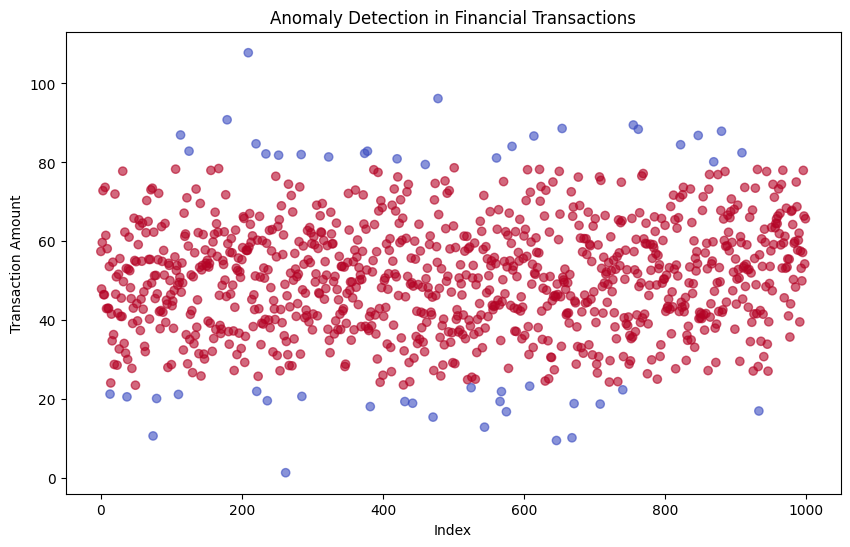

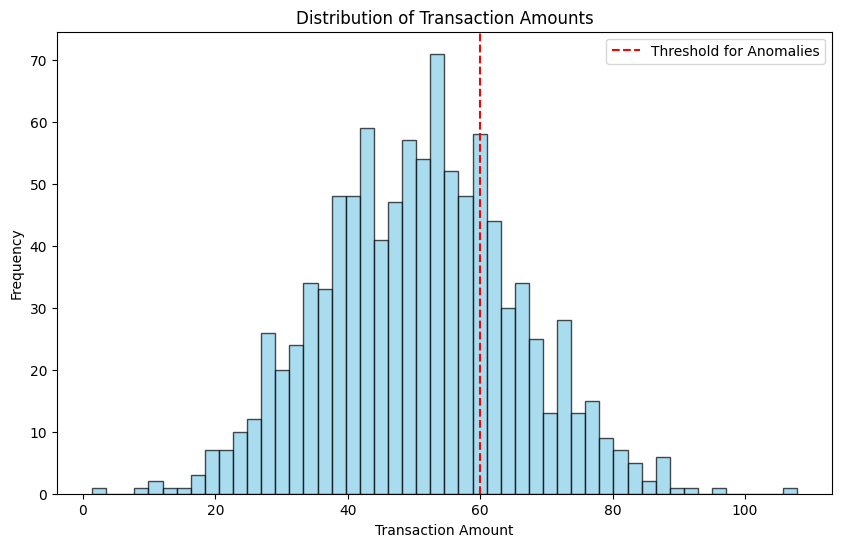

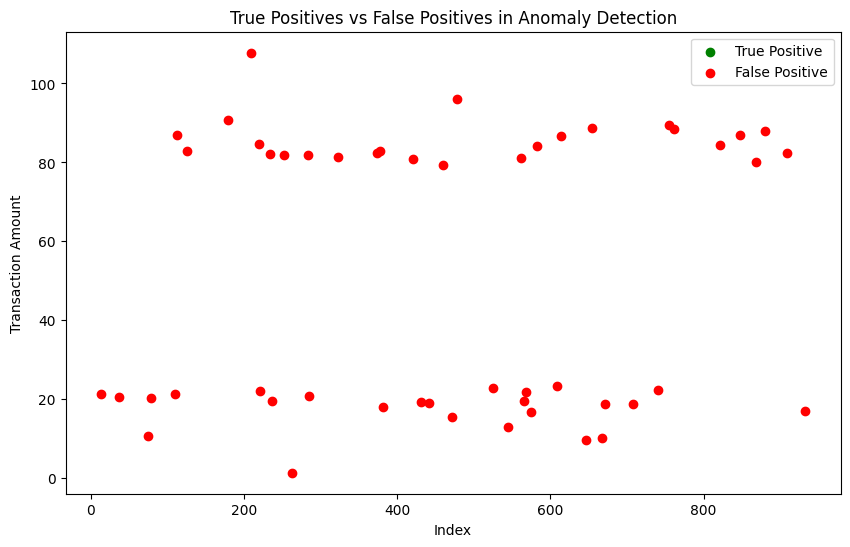

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to generate synthetic financial data for anomaly detection
def generate_synthetic_data(n_samples=1000, anomaly_fraction=0.05):
    np.random.seed(42)
    
    # Generate normal transaction amounts: Normally distributed around $50
    normal_data = np.random.normal(loc=50, scale=15, size=int(n_samples * (1 - anomaly_fraction)))
    
    # Generate anomalous transactions: Normally distributed, close to the normal data (mean=60, std=10)
    anomalous_data = np.random.normal(loc=60, scale=10, size=int(n_samples * anomaly_fraction))
    
    # Combine normal and anomalous data (no shuffling)
    all_data = np.concatenate([normal_data, anomalous_data])
    
    # Create a DataFrame with required columns
    df = pd.DataFrame(all_data, columns=['Amount'])
    
    # Optionally add 'Transaction ID' (if needed for your use case)
    df['Transaction_ID'] = range(1, n_samples + 1)
    
    # Optionally add 'Date' column (set to current date for simplicity)
    df['Date'] = pd.to_datetime('today').normalize()
    
    return df

# Generate synthetic financial data
n_samples = 1000
data = generate_synthetic_data(n_samples=n_samples)

# Save data to CSV (for your main code to load)
data.to_csv('financial_data.csv', index=False)

# Initialize the Isolation Forest model with 5% contamination
model = IsolationForest(contamination=0.05, random_state=42)

# Fit the model
X = data[['Amount']]
data['Anomaly'] = model.fit_predict(X)

# Anomalies are labeled as -1, normal data as 1
anomalies = data[data['Anomaly'] == -1]

# Display the anomalies
print("Detected Anomalies:")
print(anomalies)

# Ground truth: We know that anomalies are values around 60, close to normal values
ground_truth = np.concatenate([np.ones(int(n_samples * (1 - 0.05))), np.full(int(n_samples * 0.05), -1)])

# Calculate Precision, Recall, and F1-Score
precision = precision_score(ground_truth, data['Anomaly'])
recall = recall_score(ground_truth, data['Anomaly'])
f1 = f1_score(ground_truth, data['Anomaly'])

# Display numerical metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot 1: Anomaly Detection Results
plt.figure(figsize=(10,6))
plt.scatter(data.index, data['Amount'], c=data['Anomaly'], cmap='coolwarm', alpha=0.6)
plt.title('Anomaly Detection in Financial Transactions')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.show()

# Plot 2: Histogram of Transaction Amounts
plt.figure(figsize=(10,6))
plt.hist(data['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=60, color='r', linestyle='--', label="Threshold for Anomalies")
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot 3: True Positive vs False Positive Anomalies
plt.figure(figsize=(10,6))
tp = data[(data['Anomaly'] == -1) & (ground_truth == -1)]
fp = data[(data['Anomaly'] == -1) & (ground_truth == 1)]

plt.scatter(tp.index, tp['Amount'], color='g', label='True Positive')
plt.scatter(fp.index, fp['Amount'], color='r', label='False Positive')
plt.title('True Positives vs False Positives in Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.legend()
plt.show()


In [4]:
#below with above data but installation of precision recall curve

Detected Anomalies:
         Amount  Transaction_ID       Date  Anomaly
13    21.300796              14 2025-04-04       -1
37    20.604948              38 2025-04-04       -1
74    10.703823              75 2025-04-04       -1
79    20.186466              80 2025-04-04       -1
110   21.218432             111 2025-04-04       -1
113   86.948632             114 2025-04-04       -1
125   82.856834             126 2025-04-04       -1
179   90.802537             180 2025-04-04       -1
209  107.790972             210 2025-04-04       -1
220   84.719879             221 2025-04-04       -1
221   21.991022             222 2025-04-04       -1
234   82.159161             235 2025-04-04       -1
236   19.622861             237 2025-04-04       -1
252   81.832343             253 2025-04-04       -1
262    1.380990             263 2025-04-04       -1
284   81.995501             285 2025-04-04       -1
285   20.718683             286 2025-04-04       -1
323   81.385809             324 2025-04-04  

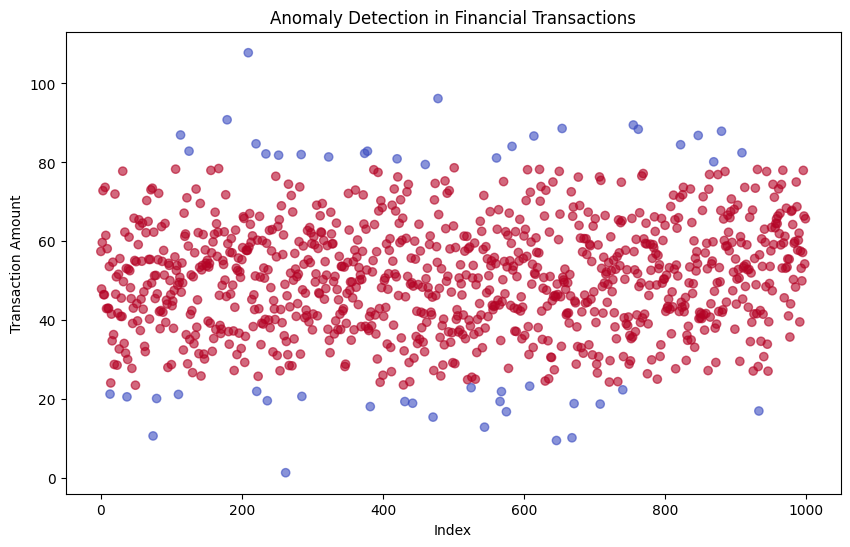

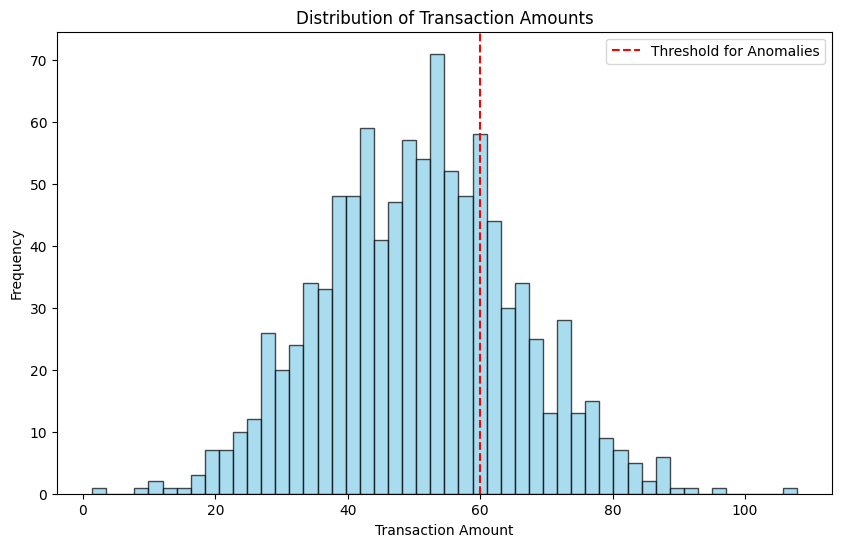

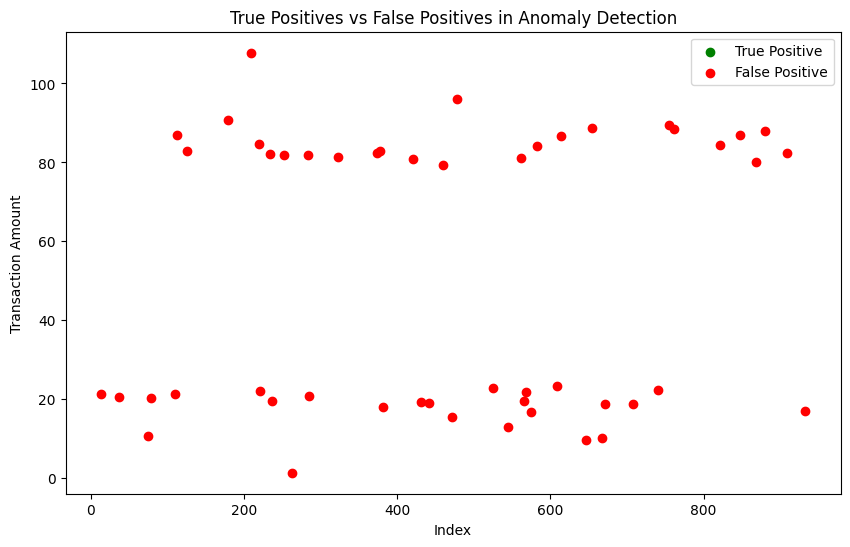

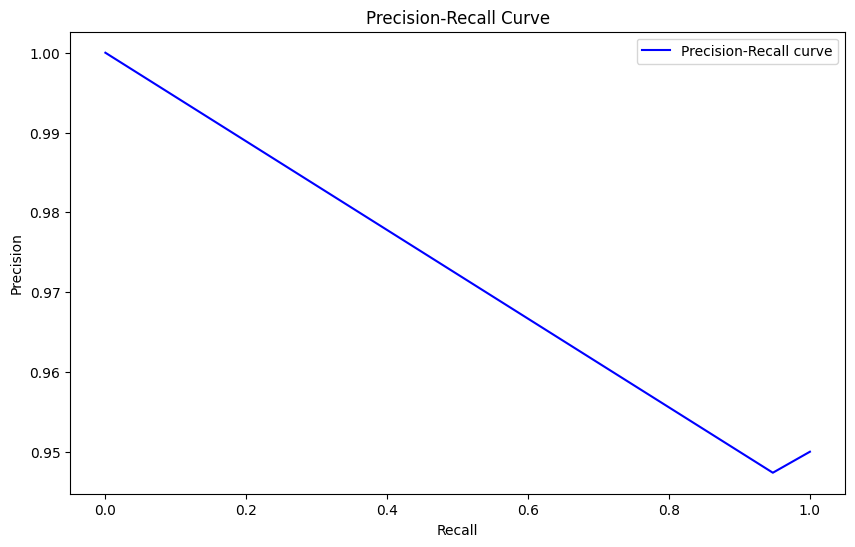

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

# Function to generate synthetic financial data for anomaly detection
def generate_synthetic_data(n_samples=1000, anomaly_fraction=0.05):
    np.random.seed(42)
    
    # Generate normal transaction amounts: Normally distributed around $50
    normal_data = np.random.normal(loc=50, scale=15, size=int(n_samples * (1 - anomaly_fraction)))
    
    # Generate anomalous transactions: Normally distributed, close to the normal data (mean=60, std=10)
    anomalous_data = np.random.normal(loc=60, scale=10, size=int(n_samples * anomaly_fraction))
    
    # Combine normal and anomalous data (no shuffling)
    all_data = np.concatenate([normal_data, anomalous_data])
    
    # Create a DataFrame with required columns
    df = pd.DataFrame(all_data, columns=['Amount'])
    
    # Optionally add 'Transaction ID' (if needed for your use case)
    df['Transaction_ID'] = range(1, n_samples + 1)
    
    # Optionally add 'Date' column (set to current date for simplicity)
    df['Date'] = pd.to_datetime('today').normalize()
    
    return df

# Generate synthetic financial data
n_samples = 1000
data = generate_synthetic_data(n_samples=n_samples)

# Save data to CSV (for your main code to load)
data.to_csv('financial_data.csv', index=False)

# Initialize the Isolation Forest model with 5% contamination
model = IsolationForest(contamination=0.05, random_state=42)

# Fit the model
X = data[['Amount']]
data['Anomaly'] = model.fit_predict(X)

# Anomalies are labeled as -1, normal data as 1
anomalies = data[data['Anomaly'] == -1]

# Display the anomalies
print("Detected Anomalies:")
print(anomalies)

# Ground truth: We know that anomalies are values around 60, close to normal values
ground_truth = np.concatenate([np.ones(int(n_samples * (1 - 0.05))), np.full(int(n_samples * 0.05), -1)])

# Calculate Precision, Recall, and F1-Score
precision = precision_score(ground_truth, data['Anomaly'])
recall = recall_score(ground_truth, data['Anomaly'])
f1 = f1_score(ground_truth, data['Anomaly'])

# Display numerical metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot 1: Anomaly Detection Results
plt.figure(figsize=(10,6))
plt.scatter(data.index, data['Amount'], c=data['Anomaly'], cmap='coolwarm', alpha=0.6)
plt.title('Anomaly Detection in Financial Transactions')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.show()

# Plot 2: Histogram of Transaction Amounts
plt.figure(figsize=(10,6))
plt.hist(data['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=60, color='r', linestyle='--', label="Threshold for Anomalies")
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot 3: True Positive vs False Positive Anomalies
plt.figure(figsize=(10,6))
tp = data[(data['Anomaly'] == -1) & (ground_truth == -1)]
fp = data[(data['Anomaly'] == -1) & (ground_truth == 1)]

plt.scatter(tp.index, tp['Amount'], color='g', label='True Positive')
plt.scatter(fp.index, fp['Amount'], color='r', label='False Positive')
plt.title('True Positives vs False Positives in Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Transaction Amount')
plt.legend()
plt.show()

# Plot 4: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(ground_truth, data['Anomaly'])
plt.figure(figsize=(10,6))
plt.plot(recall_vals, precision_vals, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
